## 각 pdb에서 상위 10위 추출

In [ ]:
# 각 PDB에서 상위 10개 RMSD 값 저장
import numpy as np
import os 
import json 

pred_dir = '/home/psh/protein-frame-flow/inference_outputs/CDRFlow_v2.3.2.1_stage_2_wt_confidence_lr_1e-3/2025-10-26_10-47-26/epoch=42-step=61619/benchmark'
h3_rmsd_by_pdb = {}
top_10_rmsd_by_pdb = {}
top_rank = 25

pdb_ids = []
for pdb_id in os.listdir(pred_dir):
    if 'config' in pdb_id:
        continue  # 설정 파일은 건너뜀

    pdb_key = pdb_id.split('_')[0]  # PDB ID 정리
    pdb_ids.append(pdb_key)  # 🔹 PDB ID 리스트에 추가

    # 현재 프로젝트에서 RMSD 값 불러오기
    sub_dir = os.path.join(pred_dir, pdb_id)
    h3_cdrs = []
    for sample in os.listdir(sub_dir):
        if 'sample' not in sample:
            continue
        cdr_info = os.path.join(sub_dir, sample, "cdr_rmsd.json")
        with open(cdr_info, 'r') as f:
            data = json.load(f)
        h3_cdrs.append(data['h3_rms'])
    
    h3_rmsd_by_pdb[pdb_key] = h3_cdrs  


for pdb, rmsd_list in h3_rmsd_by_pdb.items():
    sorted_rmsd = sorted(rmsd_list, reverse=False)  # 내림차순 정렬
    top_10_rmsd_by_pdb[pdb] = sorted_rmsd[top_rank-1]  # 상위 10개 선택

# 결과 확인 (예시 출력)
top_rmsds = []
for pdb, top_rmsd in list(top_10_rmsd_by_pdb.items()):  # 상위 5개만 출력
    top_rmsds.append(top_rmsd)

print(np.mean(top_rmsds))

## 각 pdb에서 confidence 기반 Top N 뽑기 

In [ ]:
# 각 PDB에서 상위 10개 RMSD 값 저장
import numpy as np
import os 
import json 
from Bio.PDB import PDBParser

cdr_chothia = {
    "h1": (26, 32),
    "h2": (52, 56),
    "h3": (95, 102),
    "l1": (24, 34),
    "l2": (50, 56),
    "l3": (89, 97)
}

def calculate_b_factor_mean(pdb_path, start_residue=95, end_residue=102):

    parser = PDBParser(QUIET=True)


    structure = parser.get_structure("structure", pdb_path)
    
    # 첫 번째 체인 추출
    first_chain = next(iter(structure[0].get_chains()))
    b_factors = []
    for residue in first_chain:
        residue_id = residue.get_id()
        if residue_id[0] == " ":  # 표준 아미노산만 고려
            residue_number = residue_id[1]
            if start_residue <= residue_number <= end_residue:
                for atom in residue:
                    b_factors.append(atom.get_bfactor())
            
    b_factors_avg = np.mean(b_factors)

    return b_factors_avg

pred_dir = '/home/psh/protein-frame-flow/inference_outputs/CDRFlow_v2.3.2.2_stage_3_confidence/2025-12-09_16-50-34/epoch=27-step=40124/benchmark'
h3_rmsd_by_pdb = {}
b_factors_by_pdb = {}
top_n_rmsd_by_pdb = {}
top_rank = 1

pdb_ids = []
for pdb_id in os.listdir(pred_dir):
    if 'config' in pdb_id:
        continue  # 설정 파일은 건너뜀
    print(pdb_id)
    pdb_key = pdb_id.split('_')[0]  # PDB ID 정리
    pdb_ids.append(pdb_key)  # 🔹 PDB ID 리스트에 추가

    # 현재 프로젝트에서 RMSD 값 불러오기
    sub_dir = os.path.join(pred_dir, pdb_id)
    h3_cdrs = []
    h3_b_factors = []
    for sample in os.listdir(sub_dir):
        if 'sample' not in sample:
            continue
        cdr_info = os.path.join(sub_dir, sample, "cdr_rmsd.json")
        plddt_info = os.path.join(sub_dir, sample, "plddts.json")
        with open(cdr_info, 'r') as f:
            rmsd_data = json.load(f)
        with open(plddt_info, 'r') as f:
            plddt_data = json.load(f)
        h3_cdrs.append(rmsd_data['h3_rms'])
        h3_b_factors.append(plddt_data['h3_aa'])

    h3_rmsd_by_pdb[pdb_key] = h3_cdrs  
    b_factors_by_pdb[pdb_key] = h3_b_factors

for pdb, rmsd_list in h3_rmsd_by_pdb.items():
    b_factors = b_factors_by_pdb[pdb]
    top_n_b_factor = sorted(b_factors, reverse=True)[top_rank-1]
    top_n_index = b_factors.index(top_n_b_factor)
    top_n_rmsd_by_pdb[pdb] = rmsd_list[top_n_index] 

# 결과 확인 (예시 출력)
top_rmsds = []
for pdb, top_rmsd in list(top_n_rmsd_by_pdb.items()):  # 상위 5개만 출력
    top_rmsds.append(top_rmsd)

print(np.mean(top_rmsds))

### 각 모델 별 rmsd 비교 

In [ ]:
import os 
import json
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import matplotlib.patches as mpatches
from scipy.stats import ttest_ind

pred_dirs = [
    '/home/psh/protein-frame-flow/inference_outputs/CDRFlow_v2.3.2.1_stage_2/2025-10-14_00-20-37/epoch=63-step=91712_copy/benchmark',
    '/home/psh/af3_output_processed/'
]

csv_path = '/home/psh/benchmark_after210930/meta/metadata.csv'

h3_rmsd_by_pdb = {pdir: {} for pdir in pred_dirs}
h3_rmsd_by_pdb_prev = {}
h3_rmsd_by_pdb_af3 = {}

# PDB ID 수집
all_pdb_ids = set()

for pred_dir in pred_dirs:
    for pdb_id in os.listdir(pred_dir):
        if 'config' in pdb_id:
            continue  # 설정 파일은 건너뜀

        pdb_key = pdb_id.split('_')[0]  # PDB ID 정리
        all_pdb_ids.add(pdb_key)

        # 현재 프로젝트에서 RMSD 값 불러오기
        sub_dir = os.path.join(pred_dir, pdb_id)
        h3_cdrs = []
        for sample in os.listdir(sub_dir):
            if 'sample' not in sample:
                continue
            cdr_info = os.path.join(sub_dir, sample, "cdr_rmsd.json")
            with open(cdr_info, 'r') as f:
                data = json.load(f)
            h3_cdrs.append(data['h3_rms'])

        h3_rmsd_by_pdb[pred_dir][pdb_key] = h3_cdrs  

# h3 length 길이 순으로 pdb name 정렬 
df = pd.read_csv(csv_path)
df["h3_diff"] = df["h3_end"] - df["h3_start"]
df_sorted = df.sort_values(by="h3_diff", ascending=True)
sorted_pdb_ids = df_sorted["pdb_name"].tolist()
sorted_pdb_ids = [filename.split('_')[0] for filename in sorted_pdb_ids if filename.split('_')[0] in all_pdb_ids]

# PDB ID를 3등분
num_splits = 2
split_size = len(sorted_pdb_ids) // num_splits
split_pdb_ids = [sorted_pdb_ids[i * split_size:(i + 1) * split_size] for i in range(num_splits - 1)]
split_pdb_ids.append(sorted_pdb_ids[(num_splits - 1) * split_size:])  # 마지막 부분 추가

# 색상 설정
colors = ['blue', 'orange']
handles = [
    mpatches.Patch(
        color=colors[idx],
        label=dir.split('/')[5] if len(dir.split('/')) > 5 else dir.split('/')[3]
    )
    for idx, dir in enumerate(pred_dirs)
]

# 📌 그래프 그리기 (3개로 분할)
# 📌 그래프 그리기 (2개로 분할)
for i, pdb_subset in enumerate(split_pdb_ids):
    plt.figure(figsize=(12, 6))

    tenth_values = {pred_dirs[0]: [], pred_dirs[1]: []}

    for idx, pred_dir in enumerate(pred_dirs):
        h3_rmsd_sorted = [h3_rmsd_by_pdb[pred_dir].get(pdb, []) for pdb in pdb_subset]

        # 박스플롯 그리기
        boxplot = plt.boxplot(h3_rmsd_sorted, positions=np.arange(len(pdb_subset)) + (idx * 0.2), widths=0.2,
                              patch_artist=True, boxprops=dict(facecolor=colors[idx], alpha=0.5),
                              medianprops=dict(color='black'))

        # 각 PDB에 대해 낮은 것부터 10번째 값을 저장
        for rmsd_list in h3_rmsd_sorted:
            sorted_rmsd = sorted(rmsd_list)
            if len(sorted_rmsd) >= 10:
                tenth_value = sorted_rmsd[9]  # 인덱스는 0부터 시작하므로 10번째 값은 인덱스 9
            else:
                tenth_value = None  # 또는 np.nan
            tenth_values[pred_dir].append(tenth_value)

    # 중앙값 비교 후 색상 결정
    xlabel_colors = []
    for j, pdb in enumerate(pdb_subset):
        if tenth_values[pred_dirs[0]][j] < tenth_values[pred_dirs[1]][j]:
            xlabel_colors.append(colors[0])  # 첫 번째 모델 색상
        else:
            xlabel_colors.append(colors[1])  # 두 번째 모델 색상

    # 📌 PDB ID의 색상 
    plt.xticks(range(len(pdb_subset)), pdb_subset, rotation=90)  # color 제거

    # 📌 x축 레이블 개별적으로 색상 설정
    ax = plt.gca()  # 현재 축 가져오기
    for label, color in zip(ax.get_xticklabels(), xlabel_colors):
        label.set_color(color)


    # 그래프 설정
    plt.xlabel("PDB ID")
    plt.ylabel("H3 CDR RMSD")
    plt.title(f"H3 CDR RMSD by PDB ID (Part {i+1})")
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.legend(handles=handles)

    # 그래프 표시
    plt.show()



## 모델 별 boxplot 

In [ ]:
import os
import json
import numpy as np
import matplotlib.pyplot as plt
from typing import Dict, List

CDR_KEYS = ["h1_rms", "h2_rms", "h3_rms", "l1_rms", "l2_rms", "l3_rms"]
CDR_LABELS = ["H1", "H2", "H3", "L1", "L2", "L3"]


def collect_cdr_rmsds(base_dir: str) -> Dict[str, List[float]]:
    """
    base_dir/
      └── pdb_id/
          └── sample_xxx/
              └── cdr_rmsd.json
    """
    rmsds = {k: [] for k in CDR_KEYS}

    for pdb in os.listdir(base_dir):
        if "config" in pdb:
            continue

        pdb_dir = os.path.join(base_dir, pdb)
        if not os.path.isdir(pdb_dir):
            continue

        for sample in os.listdir(pdb_dir):
            if not sample.startswith("sample"):
                continue

            json_path = os.path.join(pdb_dir, sample, "cdr_rmsd.json")
            if not os.path.exists(json_path):
                continue

            with open(json_path) as f:
                data = json.load(f)

            for k in CDR_KEYS:
                if k in data:
                    rmsds[k].append(data[k])

    return rmsds

def plot_cdr_boxplot(
    rmsd_dict: Dict[str, Dict[str, List[float]]],
    ylabel: str = "RMSD (Å)",
):
    n_models = len(rmsd_dict)
    n_cdrs = len(CDR_KEYS)

    fig, ax = plt.subplots(figsize=(10, 6))

    width = 0.7 / n_models
    x = np.arange(n_cdrs)

    # 모델별 색상
    colors = {
        "CDRFlow v2": "#1f77b4",
        "CDRFlow v1": "#ff7f0e",
        "AlphaFold3": "#2ca02c",
    }

    for i, (model, cdr_data) in enumerate(rmsd_dict.items()):
        values = [cdr_data[k] for k in CDR_KEYS]
        positions = x - 0.35 + width / 2 + i * width
        color = colors.get(model, None)

        ax.boxplot(
            values,
            positions=positions,
            widths=width,
            patch_artist=True,
            showfliers=False,
            boxprops=dict(facecolor=color, alpha=0.6),
            medianprops=dict(color="black", linewidth=2),
            whiskerprops=dict(linewidth=1.5),
            capprops=dict(linewidth=1.5),
        )

        # mean을 점선으로 표시
        for pos, v in zip(positions, values):
            if len(v) == 0:
                continue
            mean_val = np.mean(v)
            ax.hlines(
                mean_val,
                pos - width / 2,
                pos + width / 2,
                colors="black",
                linestyles="dashed",
                linewidth=1.8,
                zorder=3,
            )

    ax.set_xticks(x)
    ax.set_xticklabels(CDR_LABELS, fontsize=13)
    ax.set_ylabel(ylabel, fontsize=14)
    ax.grid(True, axis="y")

    # 범례 (색상 + mean/median 설명)
    legend_elements = [
        plt.Line2D([0], [0], color=colors[m], lw=8, alpha=0.6, label=m)
        for m in rmsd_dict.keys()
    ] 

    ax.legend(handles=legend_elements, fontsize=12, loc="upper right")

    plt.tight_layout()
    plt.show()



experiment_dirs = {
    "CDRFlow v2": "/home/psh/protein-frame-flow/inference_outputs/CDRFlow_v2.3.2.1_stage_2/2025-10-14_00-20-37/epoch=63-step=91712_copy/benchmark",
    "CDRFlow v1": "/home/psh/protein-frame-flow/inference_outputs/fm_hybrid/2025-05-28_17-17-52/epoch=105-step=150096_copy/run_2025-05-31_09-40-37",
    "AlphaFold3": "/home/psh/af3_output_processed",
}

rmsd_results = {
    label: collect_cdr_rmsds(path)
    for label, path in experiment_dirs.items()
}

plot_cdr_boxplot(rmsd_results)


# CDF 형태의 plot

In [ ]:
import os
import json
import numpy as np
import matplotlib.pyplot as plt
from typing import Dict, List


def collect_h3_rmsd(base_dir: str) -> np.ndarray:
    """
    base_dir/
      └── pdb_id/
          └── sample_xxx/
              └── cdr_rmsd.json
    """
    h3_rmsds: List[float] = []

    for pdb in os.listdir(base_dir):
        if 'config' in pdb:
            continue

        pdb_dir = os.path.join(base_dir, pdb)
        if not os.path.isdir(pdb_dir):
            continue

        for sample in os.listdir(pdb_dir):
            if not sample.startswith("sample"):
                continue

            json_path = os.path.join(pdb_dir, sample, "cdr_rmsd.json")
            if not os.path.exists(json_path):
                continue

            with open(json_path) as f:
                data = json.load(f)

            h3_rmsds.append(data["h3_rms"])

    return np.asarray(h3_rmsds)


def compute_cdf(values: np.ndarray, cutoffs: np.ndarray) -> np.ndarray:
    return np.array([(values <= c).mean() for c in cutoffs])


def plot_cdfs(
    rmsd_dict: Dict[str, np.ndarray],
    cutoff_max: float = 8.0,
    step: float = 0.1,
):
    cutoffs = np.arange(0, cutoff_max + step, step)

    plt.figure(figsize=(8, 6))

    for label, values in rmsd_dict.items():
        cdf = compute_cdf(values, cutoffs)
        plt.plot(cutoffs, cdf, label=label)

    plt.xlabel('H3 RMSD cutoff (Å)', fontsize=14)
    plt.ylabel('Proportion of samples', fontsize=14)
    plt.legend(fontsize=14)
    plt.grid(True)
    plt.tight_layout()
    plt.show()

experiment_dirs = {
    "CDRFlow v2": "/home/psh/protein-frame-flow/inference_outputs/CDRFlow_v2.3.2.1_stage_2/2025-10-14_00-20-37/epoch=63-step=91712_copy/benchmark",
    "CDRFlow v1": "/home/psh/protein-frame-flow/inference_outputs/fm_hybrid/2025-05-28_17-17-52/epoch=105-step=150096_copy/run_2025-05-31_09-40-37",
    "AlphaFold3": "/home/psh/af3_output_processed",
}

rmsd_results = {
    label: collect_h3_rmsd(path)
    for label, path in experiment_dirs.items()
}

plot_cdfs(rmsd_results, cutoff_max=8.0, step=0.1)


## affinity scatter plot 

/tmp/ipykernel_2303860/1940218390.py:102: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(loc="lower right")


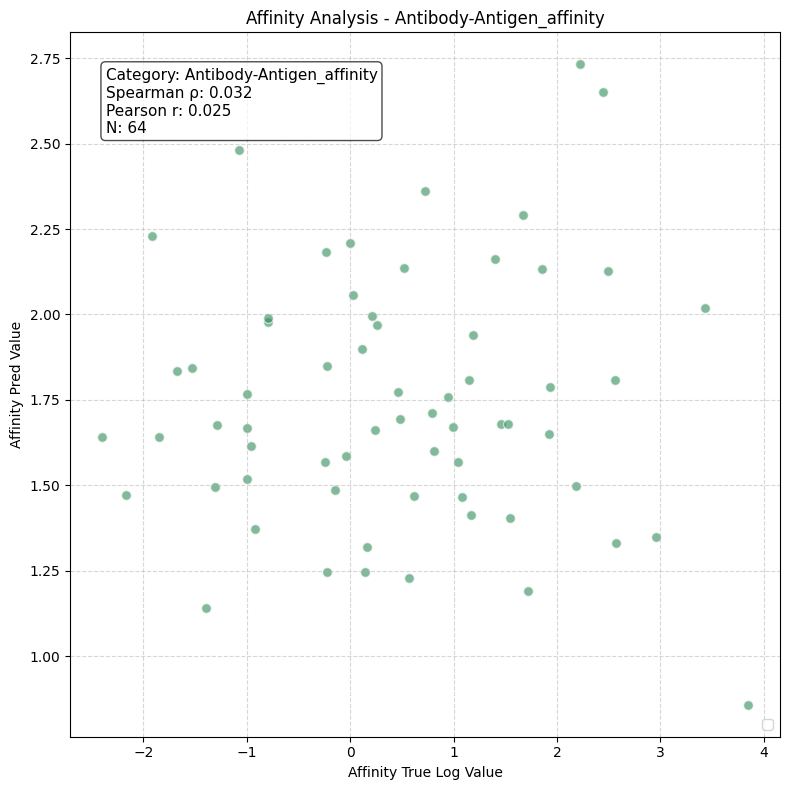

In [106]:
import os
import json
import glob
import matplotlib.pyplot as plt
from scipy.stats import spearmanr, pearsonr


# -------------------------------------------------
# 1. 필터링할 카테고리
# -------------------------------------------------
select_category = "Antibody-Antigen_affinity" # Unknown_affinity, TCR-pMHC_affinity, Antibody-Antigen_affinity


# -------------------------------------------------
# 2. 경로 설정
# -------------------------------------------------
base_path = "/home/psh/protein-frame-flow/inference_outputs/v2.4.0_affinity_no_norm_g_reg/2026-02-15_17-43-19/epoch=2-step=102/run_2026-02-15_20-13-44"


# -------------------------------------------------
# 3. 파일 찾기
# -------------------------------------------------
json_files = glob.glob(
    os.path.join(base_path, "**/sample_0_affinity.json"),
    recursive=True
)


preds = []
trues = []
found_count = 0


# -------------------------------------------------
# 4. 데이터 로드 및 필터링
# -------------------------------------------------
for file_path in json_files:
    with open(file_path, "r") as f:
        data = json.load(f)

    if data.get("category") == select_category:
        p = data.get("affinity_pred_value")
        t = data.get("affinity_true_log_value")

        if p is not None and t is not None:
            preds.append(float(p))
            trues.append(float(t))
            found_count += 1


# -------------------------------------------------
# 5. 시각화
# -------------------------------------------------
if len(preds) > 0:

    spearman_corr, _ = spearmanr(trues, preds)
    pearson_corr, _ = pearsonr(trues, preds)

    plt.figure(figsize=(8, 8))

    plt.scatter(
        trues,
        preds,
        alpha=0.6,
        edgecolors="w",
        s=50,
        color="seagreen"
    )

    # -----------------------------
    # 동일 스케일을 위한 범위 계산
    # -----------------------------
    all_vals = trues + preds
    v_min = min(all_vals)
    v_max = max(all_vals)

    # -----------------------------
    # ★ x/y 비율 동일
    # -----------------------------

    stats_text = (
        f"Category: {select_category}\n"
        f"Spearman ρ: {spearman_corr:.3f}\n"
        f"Pearson r: {pearson_corr:.3f}\n"
        f"N: {found_count}"
    )

    plt.gca().text(
        0.05,
        0.95,
        stats_text,
        transform=plt.gca().transAxes,
        fontsize=11,
        verticalalignment="top",
        bbox=dict(boxstyle="round", facecolor="white", alpha=0.7)
    )

    plt.xlabel("Affinity True Log Value")
    plt.ylabel("Affinity Pred Value")
    plt.title(f"Affinity Analysis - {select_category}")

    plt.legend(loc="lower right")
    plt.grid(True, linestyle="--", alpha=0.5)

    plt.tight_layout()
    plt.show()

else:
    print(f"경고: '{select_category}' 카테고리에 해당하는 데이터를 찾지 못했습니다.")
    print("실제 JSON에 들어있는 카테고리 예시를 확인해보세요.")


## pairformer 비교 및 시각화 

In [ ]:
import torch
import matplotlib.pyplot as plt
from Bio import PDB
import re 

# --------------------------
# 1. Load tensors
# --------------------------
file_1 = "/home/psh/protein-frame-flow/inference_outputs/CDRFlow_v2.3.2.1_stage_2_ori_perturb_stage3/2025-12-06_22-56-57/epoch=52-step=75949_copy/5ggs_optimab/5ggs_H_L_A_A24G_S25T_T28I_T30S_Y32T_M34I__S54L__Y101K_R102N_Y109L/pair.pt"
file_2 = "/home/psh/protein-frame-flow/inference_outputs/CDRFlow_v2.3.2.1_stage_2_ori_perturb_stage3/2025-12-06_22-56-57/epoch=52-step=75949_copy/5ggs_dms/5ggs_H_L_A_WT__WT__WT/pair.pt"
mt_1 = torch.load(file_1, map_location='cpu')
mt_2 = torch.load(file_2, map_location='cpu')

pure_mt_1 = file_1.split('/')[-2].replace("5ggs_H_L_A_", "")
pure_mt_2 = file_2.split('/')[-2].replace("5ggs_H_L_A_", "")

# --------------------------
# 2. Compute absolute mean difference
# --------------------------
tensor_2d = (mt_1['z'] - mt_2['z']).abs().mean(dim=-1)  # shape [L, L]
L = tensor_2d.shape[0]

# --------------------------
# 3. Load loop mask (no PDB mapping)
# --------------------------
loop_mask_1 = mt_1['loop_mask']  # [L]
loop_mask_2 = mt_2['loop_mask']  # [L]

print(loop_mask_1)

# CDR index list
cdr_indices = (loop_mask_1 == 1).nonzero(as_tuple=True)[0].tolist()

print("CDR index list:", cdr_indices)

# --------------------------
# Visualization
# --------------------------
fig, ax = plt.subplots(figsize=(7,7))
im = ax.imshow(tensor_2d.cpu().numpy(), aspect='equal', vmin=0.0, vmax=4.0)
plt.colorbar(im, ax=ax)
ax.set_title(f"|{pure_mt_1} - {pure_mt_2}|")

146
plt.tight_layout()
plt.show()

## plddt 기반으로 가장 좋은 pdb 샘플링하기 

In [ ]:
import os 
import json 

input_dir = '/home/psh/protein-frame-flow/inference_outputs/CDRFlow_v2.3.2.2_stage_3_confidence_only_plddt/2025-12-12_09-21-35/epoch=27-step=40124/run_2025-12-22_14-15-11/fold_gkr_01l_ec24_ca_3_model_0'
plddts = {}
metrics = ['h3']

# 1. 파일 읽기 및 점수 저장
for file in os.listdir(input_dir):
    if 'plddt' not in file:
        continue 

    plddt_path = os.path.join(input_dir, file)
    try:
        with open(plddt_path, 'r') as f:
            data = json.load(f)
        
        temp_b_factor = 0
        for metric in metrics:
            # 해당 metric 키가 없을 경우를 대비해 get 사용 권장 (기본값 0)
            temp_b_factor += data.get(f'{metric}_aa', 0)

        plddts[file] = temp_b_factor
    except Exception as e:
        print(f"Error parsing {file}: {e}")

# 2. 정렬 및 Top 5 추출
# plddts.items()는 (key, value) 튜플을 반환합니다.
# key=lambda item: item[1] 은 value(점수)를 기준으로 정렬하겠다는 의미입니다.
sorted_plddts = sorted(plddts.items(), key=lambda item: item[1], reverse=True)

top_5_files = sorted_plddts[:5]

# 3. 결과 출력
print(f"=== Top 5 Files (Metric: {metrics}) ===")
for rank, (filename, score) in enumerate(top_5_files, 1):
    print(f"Rank {rank}: {filename} | Score: {score:.4f}")

# 필요하다면 파일명 리스트만 따로 저장
top_5_filenames = [item[0] for item in top_5_files]
# print(top_5_filenames)

In [108]:
import pandas as pd
from data.utils import read_pkl

# 1. 데이터 로드
valid_pdb_set = read_pkl('/home/psh/logs/val_pdb.pkl')[0]
df_meta = pd.read_csv('/home/psh/data/affinity/ppb_affinity/meta/metadata_total.csv')

# 2. 검색 최적화를 위해 valid_pdb들을 소문자 리스트로 준비
# (포함 관계 확인 시에는 정규표현식이나 루프를 활용하므로 리스트가 편리할 수 있습니다)
valid_pdbs_lower = [pdb.lower() for pdb in valid_pdb_set]

# 3. 포함 관계 확인을 위한 함수 정의
def is_valid_pdb(name):
    if pd.isna(name): # 결측치 처리
        return False
    name_lower = str(name).lower()
    # valid_pdbs_lower 중 하나라도 name_lower 안에 포함되어 있는지 확인
    return any(pdb in name_lower for pdb in valid_pdbs_lower)

# 4. 마스크 생성 및 데이터 분리
# apply를 사용하여 각 행의 pdb_name이 valid set에 포함되는지 검사
mask = df_meta['pdb_name'].apply(is_valid_pdb)

df_valid = df_meta[mask]
df_train = df_meta[~mask]

# 5. 결과 저장 (원본 metadata_total.csv는 유지됨)
df_valid.to_csv('metadata_valid_ppb.csv', index=False)
df_train.to_csv('metadata_train_ppb.csv', index=False)

# 결과 확인
print(f"전체 메타데이터: {len(df_meta)}")
print(f"Validation 메타데이터: {len(df_valid)}")
print(f"Train 메타데이터: {len(df_train)}")

전체 메타데이터: 4870
Validation 메타데이터: 982
Train 메타데이터: 3888
